In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
data = pd.read_csv("dataset.csv")

In [3]:
data["duration"] = data["End Time (s)"] - data["Begin Time (s)"]

In [4]:
data.head(10)

,Selection,View,Channel,Begin Time (s),End Time (s),Low Freq (Hz),High Freq (Hz),Species,Filename,duration
0,1,Spectrogram 1,1,110.075510,110.304424,0.0,12000.0,podocnemis_expansa,240706_0256,0.228914
1,2,Spectrogram 1,1,110.317889,110.466010,0.0,11363.6,podocnemis_expansa,240706_0256,0.148121
2,3,Spectrogram 1,1,124.141456,124.240203,0.0,9727.3,podocnemis_expansa,240706_0256,0.098747
3,4,Spectrogram 1,1,124.768063,124.968712,0.0,9909.1,podocnemis_expansa,240706_0256,0.200650
4,5,Spectrogram 1,1,124.979933,125.175183,0.0,9636.4,podocnemis_expansa,240706_0256,0.195250
5,1,Spectrogram 1,1,22.098309,22.227353,0.0,14464.3,podocnemis_expansa,240706_0257,0.129045
6,2,Spectrogram 1,1,25.810160,25.902175,0.0,15321.4,podocnemis_expansa,240706_0257,0.092014
7,3,Spectrogram 1,1,37.847273,38.089653,0.0,7714.3,podocnemis_expansa,240706_0257,0.242379
8,4,Spectrogram 1,1,40.892795,41.011881,0.0,11571.4,podocnemis_expansa,240706_0257,0.119086
9,6,Spectrogram 1,1,44.425104,44.513752,0.0,12321.4,podocnemis_expansa,240706_0257,0.088648


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 752 entries, 0 to 751
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Selection       752 non-null    int64  
 1   View            752 non-null    object 
 2   Channel         752 non-null    int64  
 3   Begin Time (s)  752 non-null    float64
 4   End Time (s)    752 non-null    float64
 5   Low Freq (Hz)   752 non-null    float64
 6   High Freq (Hz)  752 non-null    float64
 7   Species         752 non-null    object 
 8   Filename        752 non-null    object 
 9   duration        752 non-null    float64
dtypes: float64(5), int64(2), object(3)
memory usage: 58.9+ KB


In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Selection,752.0,7.050532,6.833387,1.000000,2.000000,4.000000,10.000000,36.000000
Channel,752.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Begin Time (s),752.0,126.703872,88.196792,0.000000,50.603824,114.131290,197.151297,299.091062
End Time (s),752.0,127.023286,88.189492,0.222181,50.896223,114.449352,197.391603,299.284068
Low Freq (Hz),752.0,1.110444,10.868933,0.000000,0.000000,0.000000,0.000000,169.811000
High Freq (Hz),752.0,9878.655549,5027.235120,2383.400000,6283.019000,8251.500000,12006.000000,24000.000000
duration,752.0,0.319415,0.139616,0.074586,0.233430,0.289975,0.372553,1.420879


In [7]:
soma_total = data["duration"].sum()
print(
  f"A duração total dos áudios anotados das vocalizações é de {soma_total.round(1)} segundos."
)

A duração total dos áudios anotados das vocalizações é de 240.2 segundos.


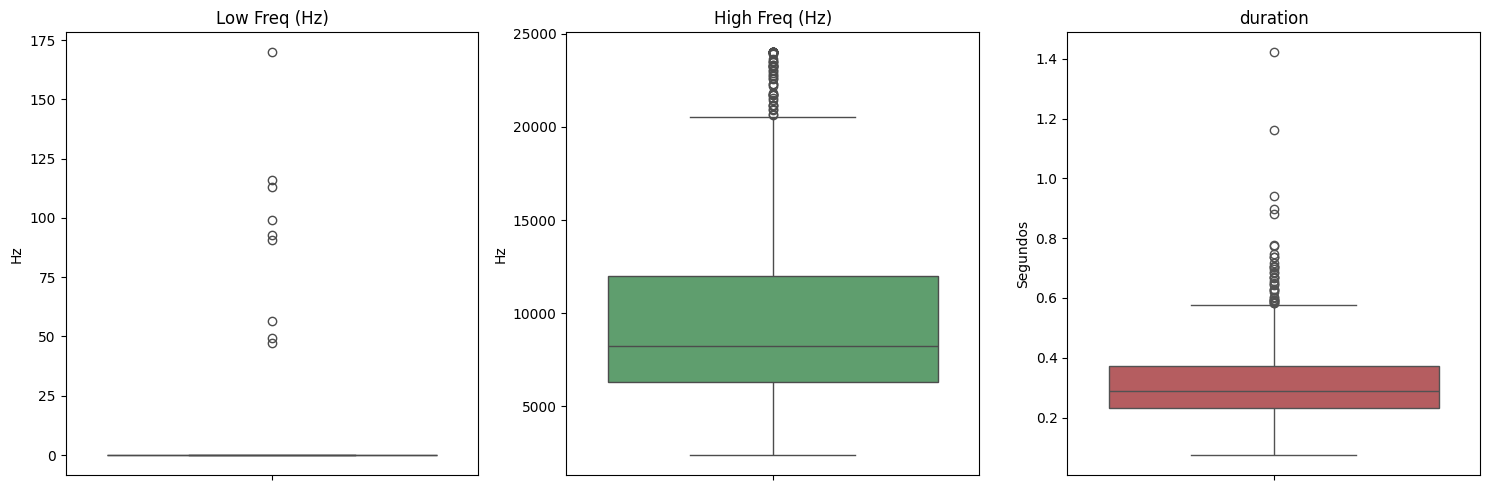

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=data["Low Freq (Hz)"], ax=axes[0], color="#4C72B0")
axes[0].set_title("Low Freq (Hz)")
axes[0].set_ylabel("Hz")

sns.boxplot(y=data["High Freq (Hz)"], ax=axes[1], color="#55A868")
axes[1].set_title("High Freq (Hz)")
axes[1].set_ylabel("Hz")

sns.boxplot(y=data["duration"], ax=axes[2], color="#C44E52")
axes[2].set_title("duration")
axes[2].set_ylabel("Segundos")

plt.tight_layout()
plt.show()

## Conclusões dos boxplots

- **Low Freq (Hz)**: a maior parte dos valores está muito próxima de zero, com poucos outliers altos. Isso sugere que, na maioria dos áudios, a energia em baixas frequências é baixa.
- **High Freq (Hz)**: os valores estão bem mais espalhados, com mediana em torno de milhares de Hz e vários outliers acima do limite superior do boxplot. Essa variável apresenta a maior variabilidade entre as três.
- **duracao_s**: a duração dos áudios está concentrada principalmente em valores curtos, com mediana por volta de alguns décimos de segundo e alguns poucos registros bem mais longos.

Em resumo, os áudios parecem ser em geral curtos, com pouca frequência baixa e com maior dispersão nas frequências altas.


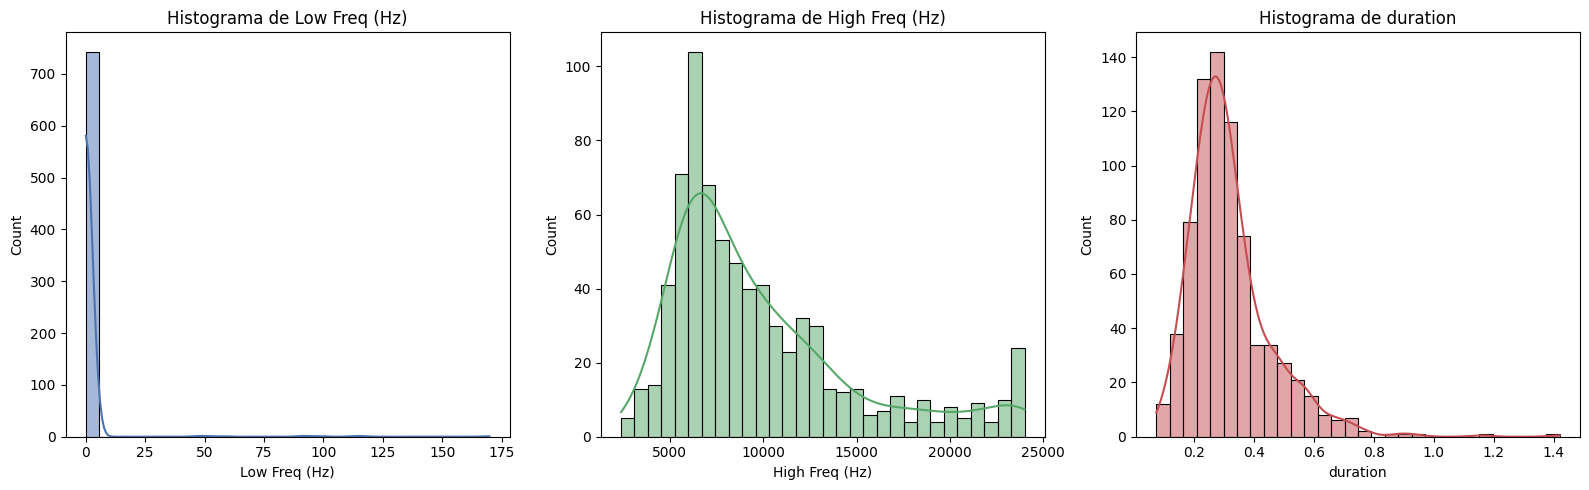

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.histplot(
  data=data, x="Low Freq (Hz)", bins=30, kde=True, ax=axes[0], color="#4C72B0"
)
axes[0].set_title("Histograma de Low Freq (Hz)")

sns.histplot(
  data=data, x="High Freq (Hz)", bins=30, kde=True, ax=axes[1], color="#55A868"
)
axes[1].set_title("Histograma de High Freq (Hz)")

sns.histplot(data=data, x="duration", bins=30, kde=True, ax=axes[2], color="#C44E52")
axes[2].set_title("Histograma de duration")

plt.tight_layout()
plt.show()

## Conclusões sobre os histogramas

- **Low Freq (Hz)**: a distribuição está fortemente concentrada próxima de zero, com uma cauda longa à direita. Isso indica que a maioria dos registros apresenta valores muito baixos de baixa frequência, com poucos casos extremos.
- **High Freq (Hz)**: os valores se concentram principalmente entre aproximadamente 5.000 e 12.000 Hz, com assimetria à direita e alguns valores altos mais dispersos. Essa é a variável com maior amplitude entre as frequências.
- **duracao_s**: a maior parte das durações está entre cerca de 0,2 e 0,4 segundos, também com cauda à direita. Isso sugere que os áudios são, em geral, curtos, com poucos trechos mais longos.

Em resumo, as três distribuições são assimétricas à direita, com presença de valores extremos, e mostram que os áudios analisados tendem a ser curtos e com variação maior nas frequências altas do que nas baixas.
